Saving fiverr_data.csv to fiverr_data.csv
DATASET OVERVIEW
Shape: (458798, 53)

Label Distribution:
label
0    446477
1     12321
Name: count, dtype: int64

Percentage:
 label
0    97.314504
1     2.685496
Name: proportion, dtype: float64

MODEL RESULTS
Accuracy: 0.9851569311246731
ROC-AUC Score: 0.9436284167336652

Classification Report:
               precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99     89296
     Spammer       0.83      0.56      0.67      2464

    accuracy                           0.99     91760
   macro avg       0.91      0.78      0.83     91760
weighted avg       0.98      0.99      0.98     91760



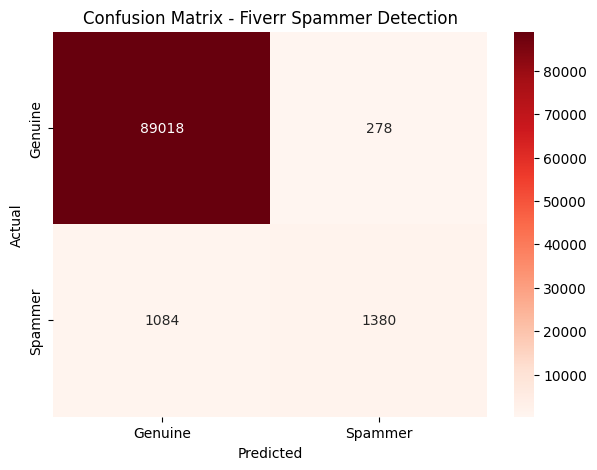


Top 10 Important Features:
 X19    0.137490
X6     0.067632
X7     0.061090
X8     0.057397
X2     0.053334
X1     0.050558
X22    0.050066
X4     0.048684
X21    0.041207
X5     0.035515
dtype: float64


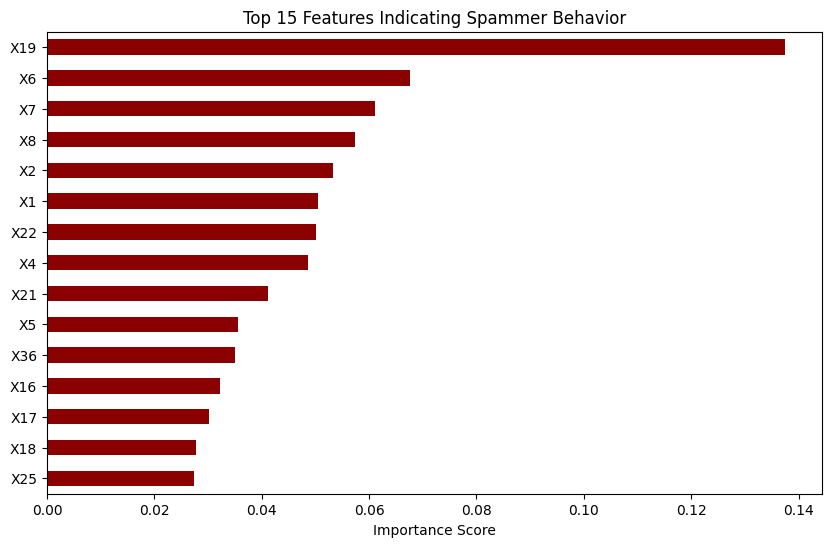

In [1]:
# CAPSTONE PROJECT 1: PREDICT POTENTIAL SPAMMERS ON FIVERR
# Student: Deepak Singh

# 1. IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 2. UPLOAD DATA
from google.colab import files
uploaded = files.upload() # Yaha fiverr_data.csv upload karo
df = pd.read_csv(list(uploaded.keys())[0])

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print("Shape:", df.shape)
print("\nLabel Distribution:")
print(df['label'].value_counts())
print("\nPercentage:\n", df['label'].value_counts(normalize=True) * 100)

# 3. DATA PREP
X = df.drop(['label', 'user_id'], axis=1)
y = df['label']

# 4. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 6. RESULTS
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

print("\n" + "="*50)
print("MODEL RESULTS")
print("="*50)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Genuine','Spammer']))

# 7. CONFUSION MATRIX - Screenshot le lena
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Genuine', 'Spammer'], yticklabels=['Genuine', 'Spammer'])
plt.title('Confusion Matrix - Fiverr Spammer Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8. FEATURE IMPORTANCE - Screenshot le lena
feature_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Important Features:\n", feature_imp.head(10))
plt.figure(figsize=(10,6))
feature_imp.head(15).plot(kind='barh', color='darkred')
plt.title('Top 15 Features Indicating Spammer Behavior')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()